# Wasserstein Regularization Analysis

This notebook performs an analysis of various models on different datasets under different levels of **Wasserstein regularization** to check if the regularization harms performance across key metrics (RMSE, MAE, NDCG@10, and MAP@10).

### Visualization Design
- Plots parallel horizontal charts (RMSE, NDCG@10, and MAP@10) for each dataset and model combination.
- Uses elegant, modern boxplots for each regularization level to show distribution over folds.
- Superimposes a trend line connecting the means over the folds.
- Omits titles on saved figures for a clean, publication-ready design.
- Dynamically saves the high-resolution visualization as `{database name}-{model name}-wasserstein.png`.

In [2]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Directory & Path Setup
Detect whether the notebook is run from the project root or the `notebooks` subdirectory, ensuring paths are set correctly.

In [3]:
import os
if os.path.exists("runs"):
    runs_dir = "runs"
elif os.path.exists("../runs"):
    runs_dir = "../runs"
else:
    runs_dir = "runs"

models = ['mf_wasserstein']
datasets = ['ml-1m']

# Metric definitions: (metric key in JSON, metric display name, direction description)
metrics = [
    ('rmse', 'RMSE', 'lower is better'),
    #('mae', 'MAE', 'lower is better'),
    ('mNDCG@10', 'NDCG@10', 'higher is better'),
    ('MAP@10', 'MAP@10', 'higher is better'),
    ('kl_diverence', 'KL Divergence', 'lower is better')
]

## 2. Load and Parse Runs
Scan for all Wasserstein folders, load the setup configurations, and parse the metrics from `metrics-*.json`.

In [4]:
def load_wasserstein_data(runs_dir, datasets, models, metrics):
    records = []
    
    for db in datasets:
        for m in models:
            # Target pattern: {dataset}-{model}-{level}-{fold}
            pattern = os.path.join(runs_dir, f"{db}-{m}-*")
            folders = glob.glob(pattern)
            
            print(f"Scanning for {db} - {m}: Found {len(folders)} run folders.")
            
            for folder in folders:
                # 1. Load setup-*.json
                setup_files = glob.glob(os.path.join(folder, "setup-*.json"))
                if not setup_files:
                    continue
                    
                with open(setup_files[0], 'r') as f:
                    setup = json.load(f)
                    
                db_name = setup.get('database_name', db)
                model_name = setup.get('model_name', f"{m}")
                lambda_val = setup.get('hyperparameters', {}).get('wasserstein_lambda')
                
                # 2. Load metrics-*.json
                metrics_files = glob.glob(os.path.join(folder, "metrics-*.json"))
                if not metrics_files:
                    continue
                    
                metrics_file = metrics_files[0]
                # Parse fold number from name, e.g., 'metrics-3.json' -> 3
                fold = int(os.path.basename(metrics_file).split('-')[-1].split('.')[0])
                
                with open(metrics_file, 'r') as f:
                    metrics_data = json.load(f)
                    
                eval_metrics = metrics_data.get('eval', {})
                
                record = {
                    'database_name': db_name,
                    'model_name': model_name,
                    'wasserstein_level': lambda_val,
                    'fold': fold
                }
                
                # Dynamically load all defined metric keys
                for key, name, desc in metrics:
                    val = eval_metrics.get(key)
                    if val is not None:
                        record[key] = float(val)
                    else:
                        record[key] = np.nan
                        
                records.append(record)
                
    if not records:
        print("No matching Wasserstein run folders found. Please check your models/datasets list and runs directory.")
        return pd.DataFrame()
        
    df = pd.DataFrame(records)
    # Sort by database, model, regularization level, then fold
    df = df.sort_values(by=['database_name', 'model_name', 'wasserstein_level', 'fold']).reset_index(drop=True)
    return df

df_metrics = load_wasserstein_data(runs_dir, datasets, models, metrics)
if not df_metrics.empty:
    display(df_metrics.head(10))

Scanning for ml-1m - mf_wasserstein: Found 36 run folders.


,database_name,model_name,wasserstein_level,fold,rmse,mNDCG@10,MAP@10,kl_diverence
0,ml-1m,mf_wasserstein,0.0001,0,1.223122,0.33668,0.20270,3.351322
1,ml-1m,mf_wasserstein,0.0001,1,1.132454,0.36562,0.23339,3.916182
2,ml-1m,mf_wasserstein,0.0001,3,1.111085,0.53461,0.40128,5.146232
3,ml-1m,mf_wasserstein,0.0001,4,1.035720,0.55946,0.43986,5.076878
4,ml-1m,mf_wasserstein,0.0001,5,0.974439,0.60874,0.48502,5.680954
5,ml-1m,mf_wasserstein,0.0010,0,1.222181,0.33760,0.20286,3.385721
6,ml-1m,mf_wasserstein,0.0010,1,1.133963,0.36989,0.23884,3.791192
7,ml-1m,mf_wasserstein,0.0010,2,1.094431,0.40676,0.27615,4.132538
8,ml-1m,mf_wasserstein,0.0010,3,1.109866,0.47994,0.34578,4.259486
9,ml-1m,mf_wasserstein,0.0010,4,1.035678,0.56072,0.44153,4.758110


## 3. Quantitative Summary Table
Compute the mean and standard deviation of each metric over the folds for each Wasserstein regularization level.

In [5]:
if not df_metrics.empty:
    unique_combinations = df_metrics.groupby(['database_name', 'model_name']).size().index.tolist()
    
    for db_name, model_name in unique_combinations:
        print(f"\n==================================================================")
        print(f"QUANTITATIVE SUMMARY TABLE FOR {db_name.upper()} - {model_name.upper()}")
        print(f"==================================================================")
        
        sub_df = df_metrics[(df_metrics['database_name'] == db_name) & (df_metrics['model_name'] == model_name)]
        
        # Dynamically build aggregation dict for active metric keys
        agg_dict = {key: ['mean', 'std'] for key, name, desc in metrics if key in sub_df.columns}
        
        # Group by level and calculate mean and std
        summary_df = sub_df.groupby('wasserstein_level').agg(agg_dict)
        
        # Format nicely
        summary_df.columns = [f"{col[0]}_{col[1]}" for col in summary_df.columns]
        display(summary_df)
else:
    print("No metrics data available to generate summary tables.")


QUANTITATIVE SUMMARY TABLE FOR ML-1M - MF_WASSERSTEIN


,rmse_mean,rmse_std,mNDCG@10_mean,mNDCG@10_std,MAP@10_mean,MAP@10_std,kl_diverence_mean,kl_diverence_std
wasserstein_level,,,,,,,,
0.0001,1.095364,0.095033,0.481022,0.121951,0.352450,0.126689,4.634314,0.963738
0.0010,1.095257,0.084536,0.459545,0.106530,0.330088,0.110630,4.413244,0.968386
0.0100,1.094879,0.084792,0.452767,0.105198,0.323503,0.109993,4.422948,0.886040
0.1000,1.095288,0.085230,0.456385,0.110399,0.327238,0.115381,4.370412,0.958375
0.5000,1.091985,0.090641,0.449982,0.102692,0.319610,0.109009,4.260187,0.659521
1.0000,1.091595,0.092803,0.464460,0.096711,0.334815,0.103024,4.176548,0.507968


## 4. Visualization
Generate three parallel charts plotted horizontally showing RMSE, NDCG@10, and MAP@10. 

- Plots a series of boxplots representing fold distributions.
- Draws a connecting trend line showing the mean performance at each level.
- Saves the clean, title-less, high-resolution visualization as `{database name}-{model name}-wasserstein.png`.


Generating parallel boxplot visualization for: ml-1m - mf_wasserstein


/tmp/ipykernel_25114/1768175891.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_25114/1768175891.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_25114/1768175891.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_25114/1768175891.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Successfully saved premium parallel visualization to: ml-1m-mf_wasserstein-wasserstein.png


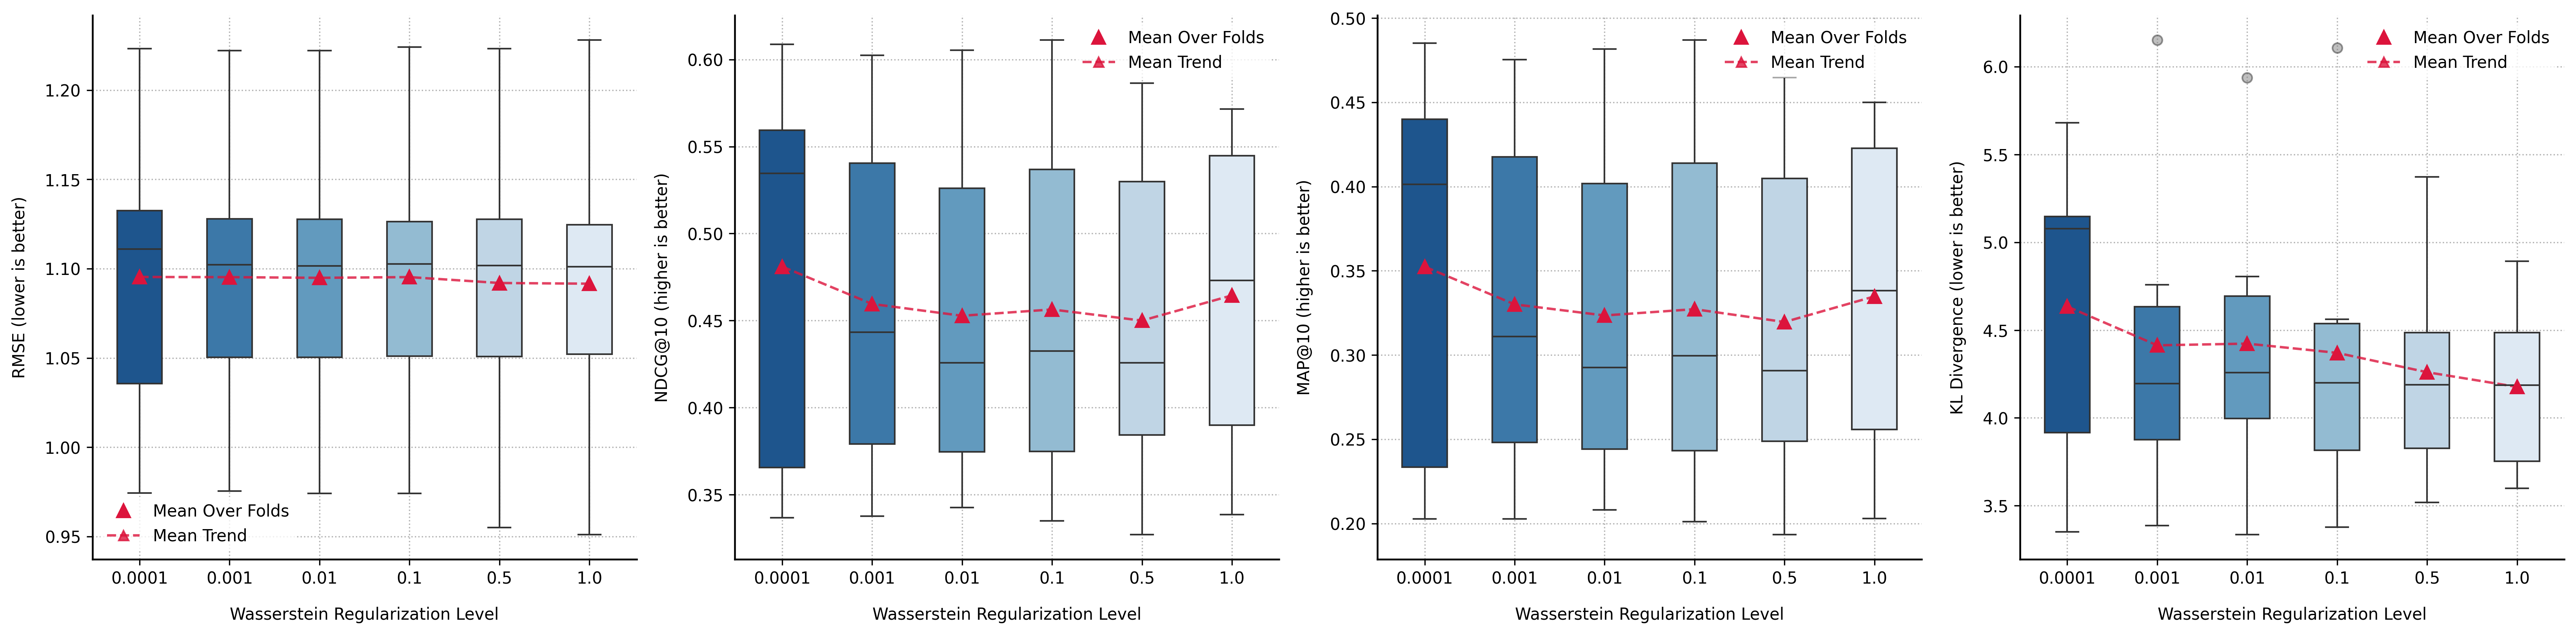

In [6]:
if not df_metrics.empty:
    unique_combinations = df_metrics.groupby(['database_name', 'model_name']).size().index.tolist()
    
    for db_name, model_name in unique_combinations:
        print(f"\nGenerating parallel boxplot visualization for: {db_name} - {model_name}")
        
        sub_df = df_metrics[(df_metrics['database_name'] == db_name) & (df_metrics['model_name'] == model_name)]
        
        # Compute levels and order
        levels = sorted(sub_df['wasserstein_level'].unique())
        
        # Filter metrics that exist in the dataframe columns
        active_metrics = [(key, name, desc) for key, name, desc in metrics if key in sub_df.columns]
        num_metrics = len(active_metrics)
        
        # 1. Setup the figure dynamically based on the number of active metrics
        fig, axes = plt.subplots(1, num_metrics, figsize=(5.5 * num_metrics, 5.5), dpi=300)
        
        # Ensure axes is iterable even if there is only 1 metric
        if num_metrics == 1:
            axes = [axes]
            
        # Palette matching regularization levels
        palette = sns.color_palette("Blues_r", len(levels))
        
        for (col_name, label, direction), ax in zip(active_metrics, axes):
            # Beautiful modern boxplot with fold mean superimposed
            sns.boxplot(
                x='wasserstein_level',
                y=col_name,
                data=sub_df,
                ax=ax,
                order=levels,
                palette=palette,
                width=0.5,
                showmeans=True,
                meanprops={"marker": "^", "markerfacecolor": "crimson", "markeredgecolor": "crimson", "markersize": 8, "label": "Mean Over Folds"},
                flierprops={"marker": "o", "markerfacecolor": "gray", "alpha": 0.5}
            )
            
            # Add dashed red trend line connecting means across levels
            means = [sub_df[sub_df['wasserstein_level'] == lvl][col_name].mean() for lvl in levels]
            ax.plot(
                range(len(levels)), 
                means, 
                color='crimson', 
                linestyle='--',
                linewidth=1.5, 
                marker='^', 
                alpha=0.8, 
                label='Mean Trend'
            )
            
            # Clean scientific grid & spines
            ax.grid(True, linestyle=':', alpha=0.6, color='gray')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.1)
            ax.spines['bottom'].set_linewidth(1.1)
            
            # Labeling (No title as requested)
            ax.set_xlabel('Wasserstein Regularization Level', labelpad=12)
            ax.set_ylabel(f"{label} ({direction})", labelpad=10)
            
            # Legends (Keep unique labels for cleaner legend)
            handles, labels_list = ax.get_legend_handles_labels()
            by_label = dict(zip(labels_list, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='best', frameon=True, facecolor='white', edgecolor='none')
            
        plt.tight_layout()
        
        # 3. Save the figure using database name and model name from data
        filename = f"{db_name}-{model_name}-wasserstein.png"
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Successfully saved premium parallel visualization to: {filename}")
        plt.show()
else:
    print("No metrics data available to generate visualizations.")

## 5. Ratings Distribution Comparison
Generate a grid of observed vs. model predicted ratings distribution charts horizontally.

- **Grid Structure**: 2 rows x n columns (where n is the number of datasets).
- **Row 1**: Observed ratings distribution (discrete bar chart) from the test fold (the last fold *k* of the time series cross validation).
- **Row 2**: Model predicted ratings distribution (continuous density plot with KDE) from the corresponding *k*-th fold prediction file `eval_error_conf-{k}.csv`.

In [7]:
# 1. Gather ratings distribution data for each dataset
datasets_data = []

for db in datasets:
    # Use the first model in the list as the reference model
    m = models[0] if models else 'mf'
    
    # Find last fold k and its folder
    pattern = os.path.join(runs_dir, f"{db}-{m}-*")
    folders = glob.glob(pattern)
    
    if not folders:
        print(f"No run folders found for dataset: {db} (model: {m})")
        continue
        
    fold_folders = []
    for f in folders:
        parts = os.path.basename(f).split('-')
        try:
            fold = int(parts[-1])
            fold_folders.append((fold, f))
        except ValueError:
            continue
            
    if not fold_folders:
        print(f"No valid fold folders found for dataset: {db} (model: {m})")
        continue
        
    # Last fold k is the maximum fold number
    max_fold = max(fold_folders, key=lambda x: x[0])[0]
    
    # Filter folders with max_fold and select the first one (smallest lambda)
    candidates = [f for fold, f in fold_folders if fold == max_fold]
    selected_folder = candidates[0]
    
    # Path to eval_error_conf-{k}.csv (checking actually existing file extension)
    csv_file = os.path.join(selected_folder, f"eval_error_conf-{max_fold}.csv")
    if not os.path.exists(csv_file):
        csv_files = glob.glob(os.path.join(selected_folder, "eval_error_conf-*.csv"))
        if csv_files:
            csv_file = csv_files[0]
        else:
            print(f"Could not find eval_error_conf file in: {selected_folder}")
            continue
            
    print(f"Loading ratings distribution from: {csv_file} (Dataset: {db}, last fold k: {max_fold})")
    
    # Read the ratings
    df_ratings = pd.read_csv(csv_file)
    datasets_data.append({
        'database_name': db,
        'model_name': m,
        'fold': max_fold,
        'observed': df_ratings['rating'].values,
        'predicted': df_ratings['r_pred'].values
    })

# 2. Plot the 2 x n grid horizontally
num_datasets = len(datasets_data)
if num_datasets > 0:
    fig, axes = plt.subplots(2, num_datasets, figsize=(5.5 * num_datasets, 9.5), dpi=300, sharex=True)
    
    # Ensure axes is a 2D array even if there is only 1 dataset
    if num_datasets == 1:
        axes = np.expand_dims(axes, axis=1)
        
    for j, data in enumerate(datasets_data):
        db_name = data['database_name']
        m_name = data['model_name']
        fold = data['fold']
        obs = data['observed']
        pred = data['predicted']
        
        # Row 1: Observed Rating Distribution (Discrete)
        ax_obs = axes[0, j]
        ratings_val, counts = np.unique(obs, return_counts=True)
        probs = counts / len(obs)
        
        ax_obs.bar(ratings_val, probs, color='SlateBlue', alpha=0.85, edgecolor='darkslateblue', width=0.5, label='Observed')
        ax_obs.set_title(f"{db_name.upper()} ({m_name.upper()})\nRow 1: Observed Ratings", fontsize=11, fontweight='bold', pad=10)
        ax_obs.set_ylabel("Probability Density", labelpad=10)
        ax_obs.set_ylim(0, max(probs) * 1.15)
        ax_obs.grid(True, linestyle=':', alpha=0.6, color='gray')
        ax_obs.spines['top'].set_visible(False)
        ax_obs.spines['right'].set_visible(False)
        ax_obs.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')
        
        # Row 2: Model Predicted Rating Distribution (Continuous)
        ax_pred = axes[1, j]
        sns.histplot(
            pred, 
            ax=ax_pred, 
            color='Tomato', 
            kde=True, 
            stat='density', 
            alpha=0.65, 
            edgecolor='chocolate', 
            label='Predicted'
        )
        ax_pred.set_title(f"Row 2: Model Predicted", fontsize=11, fontweight='bold', pad=10)
        ax_pred.set_xlabel("Rating Value", labelpad=12)
        ax_pred.set_ylabel("Probability Density", labelpad=10)
        ax_pred.set_xlim(0.5, 5.5)
        ax_pred.grid(True, linestyle=':', alpha=0.6, color='gray')
        ax_pred.spines['top'].set_visible(False)
        ax_pred.spines['right'].set_visible(False)
        ax_pred.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')
        
    plt.tight_layout()
    filename_dist = "ratings-distribution-comparison.png"
    plt.savefig(filename_dist, bbox_inches='tight', dpi=300)
    print(f"Successfully saved ratings distribution comparison visualization to: {filename_dist}")
    plt.show()
else:
    print("No rating distribution data available to plot.")

No run folders found for dataset: ml-1m (model: mf_wasserstein)
No rating distribution data available to plot.
